In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
from imblearn.under_sampling import RandomUnderSampler
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, train_test_split, learning_curve
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

# Data analyzing

In [4]:
file_path = "2019-Oct.csv"

# Loading dataset with pandas kwargs
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
file_path,
pandas_kwargs={
"nrows": 100_000, # choosing just the enough rows
"dtype": {'event_type': 'category',
       'product_id': 'int32',
       'category_code': 'category',
       'brand': 'category',
       'price': 'float32',
       'user_id': 'int32',
       }},

)

/tmp/ipykernel_2627/537055998.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [5]:
pd.options.display.max_rows = 999

In [6]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [7]:
df['user_session'].value_counts()

user_session
dab9fcec-5ecd-428a-914d-d60f3f73d32c    113
02bbe799-dc61-44c9-a745-79f1eb80d732     95
652640d0-0121-4ac4-9bf1-71407f908315     74
2c114f73-5a72-4e98-9a1c-2a0ccda20a31     73
d94ab37d-c956-4ecc-9162-b9229fdd8afd     70
                                       ... 
99ae2320-f32e-4480-85c1-de56d2e3c2e4      1
5fd8ac38-a015-4a4d-b3b3-842d4cf98821      1
d7ec739d-3b23-41f6-8847-e17554567d69      1
2484a4a5-0cdc-455c-8453-0487fb2b1d8f      1
f05121e1-6adb-4854-b1e7-e2454a20b8e7      1
Name: count, Length: 24382, dtype: int64

In [8]:
df.shape

(100000, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   event_time     100000 non-null  object  
 1   event_type     100000 non-null  category
 2   product_id     100000 non-null  int32   
 3   category_id    100000 non-null  int64   
 4   category_code  67413 non-null   category
 5   brand          85607 non-null   category
 6   price          100000 non-null  float32 
 7   user_id        100000 non-null  int32   
 8   user_session   100000 non-null  object  
dtypes: category(3), float32(1), int32(2), int64(1), object(2)
memory usage: 3.9+ MB


In [10]:
df['event_type'].value_counts(normalize=True)

event_type
view        0.97130
purchase    0.01655
cart        0.01215
Name: proportion, dtype: float64

Data question:
-If you go and check unique values and count the unique values in event_type - there are only view, cart, and purchase values - no "removed from cart" value as claimed in the dataset description?
Answer: Correct. Unfortunately, this specific retailer doesn't use remove_from_cart event. They are using override cart mechanics in API. So you can figured out removed from cart products as difference between purchase and cart events.
Source: https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/discussion/132470

In [11]:
df.isnull().sum()/df.shape[0]

event_time       0.00000
event_type       0.00000
product_id       0.00000
category_id      0.00000
category_code    0.32587
brand            0.14393
price            0.00000
user_id          0.00000
user_session     0.00000
dtype: float64

In [12]:
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.790001,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.200001,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.099976,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
5,2019-10-01 00:00:05 UTC,view,1480613,2053013561092866779,computers.desktop,pulser,908.619995,512742880,0d0d91c2-c9c2-4e81-90a5-86594dec0db9
6,2019-10-01 00:00:08 UTC,view,17300353,2053013553853497655,NaN,creed,380.959991,555447699,4fe811e9-91de-46da-90c3-bbd87ed3a65d
7,2019-10-01 00:00:08 UTC,view,31500053,2053013558031024687,NaN,luminarc,41.160000,550978835,6280d577-25c8-4147-99a7-abc6048498d6
8,2019-10-01 00:00:10 UTC,view,28719074,2053013565480109009,apparel.shoes.keds,baden,102.709999,520571932,ac1cd4e5-a3ce-4224-a2d7-ff660a105880
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb


In [13]:
df['category_code'].nunique()

123

In [14]:
df['product_id'].nunique()

20621

In [15]:
df['category_id'].nunique()

509

In [16]:
df['category_code'].nunique()

123

In [17]:
df[df['event_type']=='purchase']['user_id'].nunique()

1336

In [18]:
df[df['category_code']=='electronics.smartphone']['category_id'].value_counts()

category_id
2053013555631882655    26738
Name: count, dtype: int64

In [19]:
df[df['category_code']=='appliances.environment.water_heater'].value_counts()

event_time               event_type  product_id  category_id          category_code                        brand       price        user_id    user_session                        
2019-10-01 04:28:02 UTC  view        3900554     2053013552326770905  appliances.environment.water_heater  ariston     88.250000    542065808  a17d5faf-dd06-490f-b33c-19ffd51357bd    1
2019-10-01 00:00:00 UTC  view        3900821     2053013552326770905  appliances.environment.water_heater  aqua        33.200001    554748717  9333dfbd-b87a-4708-9857-6336556b0fcc    1
2019-10-01 00:00:13 UTC  view        3900746     2053013552326770905  appliances.environment.water_heater  haier       102.379997   555444559  98b88fa0-d8fa-4b9d-8a71-3dd403afab85    1
2019-10-01 00:00:25 UTC  view        3900990     2053013552326770905  appliances.environment.water_heater  ariston     122.180000   554748717  5459fbe4-2aa5-42b9-9064-05f853218fe0    1
2019-10-01 00:00:31 UTC  view        3900746     2053013552326770905  appliances

In [20]:
df[df['event_type']=='purchase'].value_counts()

event_time               event_type  product_id  category_id          category_code                      brand   price       user_id    user_session                        
2019-10-01 04:25:01 UTC  purchase    1005115     2053013555631882655  electronics.smartphone             apple   975.570007  547307588  6c51e580-4ba0-4868-b205-78dde69330a2    1
                                     1306797     2053013558920217191  computers.notebook                 acer    329.989990  515856194  7eb1c0d9-4b45-4682-bf26-c650b6d8c8fe    1
2019-10-01 04:25:02 UTC  purchase    1005021     2053013555631882655  electronics.smartphone             oppo    386.059998  512718177  5b9fa934-c7fa-4474-9233-709fe025a2f2    1
2019-10-01 04:25:10 UTC  purchase    1004939     2053013555631882655  electronics.smartphone             vivo    141.289993  555302580  acf77b93-7522-45db-a7de-e11825c8f0cf    1
                                     4700671     2053013560899928785  auto.accessories.videoregister     xiaomi  48

In [21]:
df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())

/tmp/ipykernel_2627/1857955882.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_groupby = df.groupby('category_code')['event_type'].apply(lambda x: (x == 'purchase').sum())


In [22]:
df_groupby.sort_values(ascending=False)

category_code
electronics.smartphone                    758
electronics.audio.headphone                67
electronics.video.tv                       41
appliances.kitchen.washer                  40
computers.notebook                         35
electronics.clocks                         35
appliances.environment.vacuum              33
appliances.kitchen.refrigerators           28
appliances.environment.air_heater          13
appliances.kitchen.blender                 11
electronics.telephone                      10
apparel.shoes                               8
computers.peripherals.monitor               8
auto.accessories.player                     7
appliances.kitchen.microwave                7
accessories.bag                             7
computers.desktop                           6
computers.peripherals.printer               6
electronics.audio.subwoofer                 6
appliances.kitchen.kettle                   6
appliances.kitchen.oven                     6
appliances.environme

# Preprocessing

## Limitation aux catégories les plus vendues

In [23]:
top5 = ['electronics.smartphone', 'electronics.audio.headphone', 'electronics.video.tv',
'electronics.clocks', 'computers.notebook']

X = df[df['category_code'].isin(top5)]

In [24]:
X['category_code'].nunique()

5

In [25]:
X.shape

(37177, 9)

In [26]:
X[X['event_type']=='purchase'].shape

(936, 9)

In [27]:
X.isnull().sum()/X.shape[0]

event_time       0.000000
event_type       0.000000
product_id       0.000000
category_id      0.000000
category_code    0.000000
brand            0.016865
price            0.000000
user_id          0.000000
user_session     0.000000
dtype: float64

## Duplicates

In [28]:
X.duplicated().sort_values()

3        False
66351    False
66355    False
66356    False
66357    False
         ...  
3830      True
92383     True
92387     True
96040     True
18817     True
Length: 37177, dtype: bool

In [29]:
X.drop_duplicates()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.740005,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.979980,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d
9,2019-10-01 00:00:11 UTC,view,1004545,2053013555631882655,electronics.smartphone,huawei,566.010010,537918940,406c46ed-90a4-4787-a43b-59a410c1a5fb
11,2019-10-01 00:00:11 UTC,view,1005011,2053013555631882655,electronics.smartphone,samsung,900.640015,530282093,50a293fb-5940-41b2-baf3-17af0e812101
16,2019-10-01 00:00:18 UTC,view,1801995,2053013554415534427,electronics.video.tv,haier,193.029999,537192226,e3151795-c355-4efa-acf6-e1fe1bebeee5
...,...,...,...,...,...,...,...,...,...
99978,2019-10-01 04:28:26 UTC,view,1005105,2053013555631882655,electronics.smartphone,apple,1415.479980,555479991,403197ef-3ea1-4d5d-ad67-e4f14c18dfd6
99983,2019-10-01 04:28:26 UTC,view,1004767,2053013555631882655,electronics.smartphone,samsung,254.759995,541383474,4b170f8e-3d2e-4541-bc12-bc0b0f10020c
99984,2019-10-01 04:28:26 UTC,purchase,1004904,2053013555631882655,electronics.smartphone,huawei,110.339996,536561197,65ca1cea-cf63-4533-9981-78c06fc5b45d
99988,2019-10-01 04:28:27 UTC,view,1003304,2053013555631882655,electronics.smartphone,apple,571.559998,518088546,60cef07c-8829-4474-91c7-ce39f5eddf0b


## Modification format dates

In [30]:
X["event_time"] = pd.to_datetime(
    X["event_time"].str.replace(" UTC", "", regex=False),
    format="%Y-%m-%d %H:%M:%S",
)

/tmp/ipykernel_2627/4073158124.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["event_time"] = pd.to_datetime(


In [31]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37177 entries, 3 to 99997
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_time     37177 non-null  datetime64[ns]
 1   event_type     37177 non-null  category      
 2   product_id     37177 non-null  int32         
 3   category_id    37177 non-null  int64         
 4   category_code  37177 non-null  category      
 5   brand          36550 non-null  category      
 6   price          37177 non-null  float32       
 7   user_id        37177 non-null  int32         
 8   user_session   37177 non-null  object        
dtypes: category(3), datetime64[ns](1), float32(1), int32(2), int64(1), object(1)
memory usage: 1.7+ MB


## Concaténation

In [32]:
X_concat = (
    X.groupby(["user_session", "user_id", "category_id", "product_id"], as_index=False).
    agg({
        "event_type": " ".join,
        "event_time": (lambda x: x.max() - x.min()),
        "price": (lambda x: x.mean()),
        })
)

In [33]:
X_concat.head()

,user_session,user_id,category_id,product_id,event_type,event_time,price
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days,231.639999
1,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002528,view,0 days,643.229980
2,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002532,view,0 days,642.690002
3,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100328,view,0 days,117.879997
4,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100491,view,0 days,245.559998


In [34]:
display(min(X_concat['event_time']), max(X_concat['event_time']))

Timedelta('0 days 00:00:00')

Timedelta('0 days 03:55:25')

In [35]:
X_concat['event_type'].value_counts()

event_type
view                                                                                                                                                                                                                                                                                                               16194
view view                                                                                                                                                                                                                                                                                                           4886
view view view                                                                                                                                                                                                                                                                                                      1173
view view view view                               

In [36]:
X_concat.shape

(24038, 7)

In [37]:
X_concat['user_session'].value_counts()

user_session
dab9fcec-5ecd-428a-914d-d60f3f73d32c    64
85eb3f53-39e9-46e2-9f3a-96b204db9369    43
786ad8fa-f815-49fa-9ae5-b50efdcf6f89    36
9233707a-29ef-4f75-a3d5-2cef1d7b6f0e    33
2535e86b-ee7f-46b5-ac08-e7fb62495156    32
                                        ..
ff8e9261-51c4-4079-8a19-b44e0bb35f16     1
ff910649-15a9-423d-b129-bbf1f336a11e     1
ff97cfa8-40b7-4353-b1a8-59ff55e5cb79     1
ff9ea00f-37c5-4349-ae78-3e89a5d4a7e4     1
ffa62e58-edc9-4e1d-a0f2-76e0bc9b1be3     1
Name: count, Length: 10562, dtype: int64

Ajout de la target

In [38]:
# X_concat['purchase'] = X_concat['event_type'].str.contains('purchase').apply(int)

In [39]:
X_concat.head(10)

,user_session,user_id,category_id,product_id,event_type,event_time,price
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days 00:00:00,231.639999
1,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002528,view,0 days 00:00:00,643.229980
2,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002532,view,0 days 00:00:00,642.690002
3,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100328,view,0 days 00:00:00,117.879997
4,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100491,view,0 days 00:00:00,245.559998
5,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100564,view,0 days 00:00:00,259.980011
6,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100577,view,0 days 00:00:00,295.980011
7,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100678,view view,0 days 00:00:50,154.190002
8,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100719,view view,0 days 00:00:26,151.610001
9,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100738,view view,0 days 00:01:19,154.160004


In [40]:
X_concat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24038 entries, 0 to 24037
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype          
---  ------        --------------  -----          
 0   user_session  24038 non-null  object         
 1   user_id       24038 non-null  int32          
 2   category_id   24038 non-null  int64          
 3   product_id    24038 non-null  int32          
 4   event_type    24038 non-null  object         
 5   event_time    24038 non-null  timedelta64[ns]
 6   price         24038 non-null  float32        
dtypes: float32(1), int32(2), int64(1), object(2), timedelta64[ns](1)
memory usage: 1.0+ MB


In [41]:
X_concat['event_type'].value_counts()

event_type
view                                                                                                                                                                                                                                                                                                               16194
view view                                                                                                                                                                                                                                                                                                           4886
view view view                                                                                                                                                                                                                                                                                                      1173
view view view view                               

## Réduction du nombre d'events dans la séquence

In [42]:
X_concat['sequence_len']=X_concat['event_type'].apply(lambda x: len(x.split()))

In [43]:
X_concat = X_concat.loc[X_concat['sequence_len']<8]

In [60]:
X_concat.shape

(23952, 10)

## Travail sur X_concat et y

### Suppression du dernier event et définition du y

#### Création de la colonne 'event_list'

In [44]:
X_concat['event_list'] = X_concat['event_type'].apply(str.split)

In [45]:
X_concat['event_list']

0        [view]
1        [view]
2        [view]
3        [view]
4        [view]
          ...  
24033    [view]
24034    [view]
24035    [view]
24036    [view]
24037    [view]
Name: event_list, Length: 23952, dtype: object

#### Définition du y

In [46]:
y = X_concat['event_list'].apply(lambda x: x.pop())

In [47]:
y

0        view
1        view
2        view
3        view
4        view
         ... 
24033    view
24034    view
24035    view
24036    view
24037    view
Name: event_list, Length: 23952, dtype: object

In [48]:
y.value_counts()

event_list
view        23484
purchase      321
cart          147
Name: count, dtype: int64

In [49]:
y = y.apply(lambda x: 1 if x=='purchase' else 0)

In [50]:
y.shape

(23952,)

In [51]:
y.value_counts()

event_list
0    23631
1      321
Name: count, dtype: int64

### Remplacement des [] en ['nothing']

In [52]:
X_concat['event_list'] = X_concat['event_list'].apply(lambda x: ['nothing'] if x==[] else x)

In [53]:
X_concat['event_list']

0        [nothing]
1        [nothing]
2        [nothing]
3        [nothing]
4        [nothing]
           ...    
24033    [nothing]
24034    [nothing]
24035    [nothing]
24036    [nothing]
24037    [nothing]
Name: event_list, Length: 23952, dtype: object

### Recréation de la séquence

In [54]:
X_concat['sequence_event'] = X_concat['event_list'].apply(" ".join)

In [55]:
X_concat['sequence_event']

0        nothing
1        nothing
2        nothing
3        nothing
4        nothing
          ...   
24033    nothing
24034    nothing
24035    nothing
24036    nothing
24037    nothing
Name: sequence_event, Length: 23952, dtype: object

In [56]:
X_concat['event_type'].nunique()

132

In [57]:
X_concat

,user_session,user_id,category_id,product_id,event_type,event_time,price,sequence_len,event_list,sequence_event
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days,231.639999,1,[nothing],nothing
1,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002528,view,0 days,643.229980,1,[nothing],nothing
2,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002532,view,0 days,642.690002,1,[nothing],nothing
3,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100328,view,0 days,117.879997,1,[nothing],nothing
4,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100491,view,0 days,245.559998,1,[nothing],nothing
...,...,...,...,...,...,...,...,...,...,...
24033,ffecac06-448c-486b-861b-6325886ea93f,552722940,2053013555631882655,1004856,view,0 days,130.759995,1,[nothing],nothing
24034,ffecac06-448c-486b-861b-6325886ea93f,552722940,2053013555631882655,1004934,view,0 days,231.639999,1,[nothing],nothing
24035,ffecac06-448c-486b-861b-6325886ea93f,552722940,2053013555631882655,1004937,view,0 days,167.289993,1,[nothing],nothing
24036,ffecac06-448c-486b-861b-6325886ea93f,552722940,2053013555631882655,1005157,view,0 days,282.890015,1,[nothing],nothing


In [61]:
display(min(X_concat['sequence_len']), max(X_concat['sequence_len']))

1

7

### Calcul de la durée moyenne entre events

In [63]:
X_concat['duration_mean'] = X_concat['event_time'] / X_concat['sequence_len']

In [64]:
X_concat.head()

,user_session,user_id,category_id,product_id,event_type,event_time,price,sequence_len,event_list,sequence_event,duration_mean
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days,231.639999,1,[nothing],nothing,0 days
1,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002528,view,0 days,643.229980,1,[nothing],nothing,0 days
2,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002532,view,0 days,642.690002,1,[nothing],nothing,0 days
3,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100328,view,0 days,117.879997,1,[nothing],nothing,0 days
4,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100491,view,0 days,245.559998,1,[nothing],nothing,0 days


In [65]:
X_concat.describe()

,user_id,category_id,product_id,event_time,price,sequence_len,duration_mean
count,2.395200e+04,2.395200e+04,2.395200e+04,23952,23952.000000,23952.000000,23952
mean,5.328585e+08,2.053056e+18,2.503748e+06,0 days 00:00:55.026219104,490.356537,1.513527,0 days 00:00:19.862206257
std,1.665322e+07,1.536823e+15,4.536541e+06,0 days 00:04:18.069507044,450.689667,0.935202,0 days 00:01:41.113660426
min,4.096869e+08,2.053014e+18,1.001588e+06,0 days 00:00:00,0.000000,1.000000,0 days 00:00:00
25%,5.163309e+08,2.053014e+18,1.004575e+06,0 days 00:00:00,167.029999,1.000000,0 days 00:00:00
50%,5.310152e+08,2.053014e+18,1.004903e+06,0 days 00:00:00,308.619980,1.000000,0 days 00:00:00
75%,5.502979e+08,2.053014e+18,1.306873e+06,0 days 00:00:27,735.330017,2.000000,0 days 00:00:12.500000
max,5.554835e+08,2.109094e+18,4.550002e+07,0 days 03:55:25,2574.070068,7.000000,0 days 01:57:42.500000


In [66]:
X_concat.loc[X_concat['event_time']>'0 days 00:02:00']['user_session'].nunique()

1811

In [67]:
X.loc[X['user_session']=='0d6fd875-6b0f-46ca-a75a-257917490b25']

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session


In [68]:
df.loc[df['user_session']=='0d6fd875-6b0f-46ca-a75a-257917490b25']

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session


In [69]:
X['category_code'].value_counts()

category_code
electronics.smartphone                    26738
electronics.clocks                         3150
computers.notebook                         2687
electronics.audio.headphone                2609
electronics.video.tv                       1993
apparel.dress                                 0
apparel.costume                               0
apparel.belt                                  0
accessories.bag                               0
accessories.umbrella                          0
accessories.wallet                            0
apparel.shoes.ballet_shoes                    0
apparel.shoes.espadrilles                     0
apparel.shoes.keds                            0
apparel.shoes.moccasins                       0
apparel.shoes.sandals                         0
apparel.shoes.slipons                         0
apparel.shoes.step_ins                        0
apparel.shorts                                0
apparel.skirt                                 0
apparel.sock              

In [70]:
X_concat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23952 entries, 0 to 24037
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   user_session    23952 non-null  object         
 1   user_id         23952 non-null  int32          
 2   category_id     23952 non-null  int64          
 3   product_id      23952 non-null  int32          
 4   event_type      23952 non-null  object         
 5   event_time      23952 non-null  timedelta64[ns]
 6   price           23952 non-null  float32        
 7   sequence_len    23952 non-null  int64          
 8   event_list      23952 non-null  object         
 9   sequence_event  23952 non-null  object         
 10  duration_mean   23952 non-null  timedelta64[ns]
dtypes: float32(1), int32(2), int64(2), object(4), timedelta64[ns](2)
memory usage: 1.9+ MB


In [ ]:
# X_preprocessed = pd.merge(X_concat, .drop(columns=['event_time', 'event_type', 'brand', 'category_code', 'category_id']), on=['user_session', 'user_id', 'product_id'], how='left')

In [71]:
X_concat.head()

,user_session,user_id,category_id,product_id,event_type,event_time,price,sequence_len,event_list,sequence_event,duration_mean
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,view,0 days,231.639999,1,[nothing],nothing,0 days
1,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002528,view,0 days,643.229980,1,[nothing],nothing,0 days
2,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002532,view,0 days,642.690002,1,[nothing],nothing,0 days
3,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100328,view,0 days,117.879997,1,[nothing],nothing,0 days
4,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100491,view,0 days,245.559998,1,[nothing],nothing,0 days


### Nouveaux noms pour certaines colonnes

In [72]:
X_concat.rename(columns={'event_time': 'duration'}, inplace=True)

In [73]:
X_concat.shape

(23952, 11)

## X_preprocessed

In [74]:
X_preprocessed = X_concat.drop(columns=['event_type', 'event_list'])

In [75]:
X_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23952 entries, 0 to 24037
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   user_session    23952 non-null  object         
 1   user_id         23952 non-null  int32          
 2   category_id     23952 non-null  int64          
 3   product_id      23952 non-null  int32          
 4   duration        23952 non-null  timedelta64[ns]
 5   price           23952 non-null  float32        
 6   sequence_len    23952 non-null  int64          
 7   sequence_event  23952 non-null  object         
 8   duration_mean   23952 non-null  timedelta64[ns]
dtypes: float32(1), int32(2), int64(2), object(2), timedelta64[ns](2)
memory usage: 1.6+ MB


In [76]:
X_preprocessed['sequence_len'].mean()

np.float64(1.5135270541082164)

<Axes: >

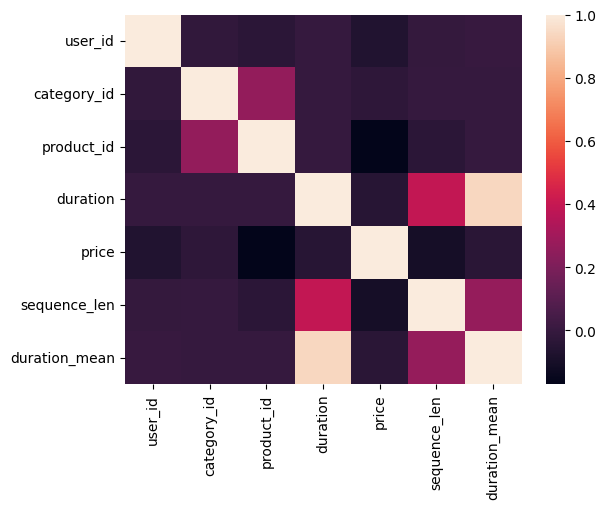

In [77]:
sns.heatmap(X_preprocessed.select_dtypes(include=np.number).corr())

In [78]:
X_preprocessed.head()

,user_session,user_id,category_id,product_id,duration,price,sequence_len,sequence_event,duration_mean
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,0 days,231.639999,1,nothing,0 days
1,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002528,0 days,643.229980,1,nothing,0 days
2,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002532,0 days,642.690002,1,nothing,0 days
3,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100328,0 days,117.879997,1,nothing,0 days
4,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100491,0 days,245.559998,1,nothing,0 days


In [79]:
X_preprocessed['duration_mean_second'] = X_preprocessed['duration_mean'].dt.total_seconds()

In [80]:
X_preprocessed.head()

,user_session,user_id,category_id,product_id,duration,price,sequence_len,sequence_event,duration_mean,duration_mean_second
0,0006852b-f9a2-4d84-b439-acc1f9e6771e,536297355,2053013555631882655,1005153,0 days,231.639999,1,nothing,0 days,0.0
1,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002528,0 days,643.229980,1,nothing,0 days,0.0
2,000c2fd2-561a-4abd-bd21-5e71449b1b78,552296408,2053013555631882655,1002532,0 days,642.690002,1,nothing,0 days,0.0
3,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100328,0 days,117.879997,1,nothing,0 days,0.0
4,001928f2-e689-446a-a5d8-27d8e1018a1c,513982020,2053013553341792533,5100491,0 days,245.559998,1,nothing,0 days,0.0


In [81]:
X_preprocessed.shape

(23952, 10)

In [82]:
y.shape

(23952,)

## Train test split

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3)

In [96]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7186 entries, 12238 to 2469
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   user_session          7186 non-null   object         
 1   user_id               7186 non-null   int32          
 2   category_id           7186 non-null   int64          
 3   product_id            7186 non-null   int32          
 4   duration              7186 non-null   timedelta64[ns]
 5   price                 7186 non-null   float32        
 6   sequence_len          7186 non-null   int64          
 7   sequence_event        7186 non-null   object         
 8   duration_mean         7186 non-null   timedelta64[ns]
 9   duration_mean_second  7186 non-null   float64        
dtypes: float32(1), float64(1), int32(2), int64(2), object(2), timedelta64[ns](2)
memory usage: 533.3+ KB


In [97]:
y_test.value_counts()

event_list
0    7078
1     108
Name: count, dtype: int64

## Undersampling

In [84]:
rus = RandomUnderSampler(sampling_strategy=0.5,random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

In [85]:
print(X_train_res.shape)
print(y_train_res.shape)
y_train_res.value_counts()

(639, 10)
(639,)


event_list
0    426
1    213
Name: count, dtype: int64

## Encoding

In [86]:
encoder = OneHotEncoder(sparse_output=False, drop="if_binary", handle_unknown="ignore").set_output(transform='pandas')

X_train_encoded = encoder.fit_transform(X_train_res[['sequence_event', 'category_id']])

In [87]:
X_test_encoded = encoder.transform(X_test[['sequence_event', 'category_id']])

/home/turpindominique/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


## Scaling

In [88]:
scaler = RobustScaler().set_output(transform='pandas')

X_train_scaled = scaler.fit_transform(X_train_res[['duration_mean_second', 'price']])
X_test_scaled = scaler.transform(X_test[['duration_mean_second', 'price']])

## Concaténation des X_train et X_test

In [99]:
X_train_processed_res = pd.concat([X_train_encoded, X_train_scaled], axis=1)
X_test_processed = pd.concat([X_test_encoded, X_test_scaled], axis=1)

In [100]:
X_train_processed_res.info()

<class 'pandas.core.frame.DataFrame'>
Index: 639 entries, 18826 to 9371
Data columns (total 36 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   sequence_event_nothing                        639 non-null    float64
 1   sequence_event_view                           639 non-null    float64
 2   sequence_event_view cart                      639 non-null    float64
 3   sequence_event_view cart cart                 639 non-null    float64
 4   sequence_event_view cart cart cart            639 non-null    float64
 5   sequence_event_view cart cart cart view       639 non-null    float64
 6   sequence_event_view cart cart view cart       639 non-null    float64
 7   sequence_event_view cart cart view view       639 non-null    float64
 8   sequence_event_view cart cart view view view  639 non-null    float64
 9   sequence_event_view cart purchase             639 non-null    flo

In [107]:
X_train_processed_res.head()

,sequence_event_nothing,sequence_event_view,sequence_event_view cart,sequence_event_view cart cart,sequence_event_view cart cart cart,sequence_event_view cart cart cart view,sequence_event_view cart cart view cart,sequence_event_view cart cart view view,sequence_event_view cart cart view view view,sequence_event_view cart purchase,...,sequence_event_view view view view view,sequence_event_view view view view view cart,category_id_2053013553341792533,category_id_2053013554415534427,category_id_2053013554658804075,category_id_2053013555631882655,category_id_2053013558920217191,category_id_2053013561579406073,duration_mean_second,price
18826,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,-0.441270
9795,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.240674,0.066574
7370,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.240674,-0.321420
12918,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.866827,0.727367
16781,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.240674,3.642342


# Entrainement du modèle

In [92]:
model = LogisticRegression(class_weight='balanced', random_state=42)

model.fit(X_train_processed, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# Metrics

In [93]:
cv_results = cross_validate(model, X_train_processed, y_train_res, scoring=['f1', 'recall', 'precision', 'accuracy'])
cv_results

{'fit_time': array([0.14772892, 0.0136342 , 0.03117108, 0.03251672, 0.01166964]),
 'score_time': array([0.01391315, 0.01174045, 0.02429128, 0.01399946, 0.01266384]),
 'test_f1': array([0.77419355, 0.7079646 , 0.71304348, 0.69565217, 0.73584906]),
 'test_recall': array([0.85714286, 0.93023256, 0.95348837, 0.93023256, 0.92857143]),
 'test_precision': array([0.70588235, 0.57142857, 0.56944444, 0.55555556, 0.609375  ]),
 'test_accuracy': array([0.8359375 , 0.7421875 , 0.7421875 , 0.7265625 , 0.77952756])}

In [101]:
train_sizes = np.arange(20, 520, 20)

# Get train scores (precision), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=LogisticRegression(class_weight='balanced'), X=X_train_processed_res, y=y_train_res, train_sizes=train_sizes, cv=5, scoring="recall")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

/home/turpindominique/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
85 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
85 fits failed with the following error:
Traceback (most recent call last):
  File "/home/turpindominique/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/turpindominique/.pyenv/versions/convertiq/lib/python3.10/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/turpindominique/.pyenv/versions/convertiq/lib/python

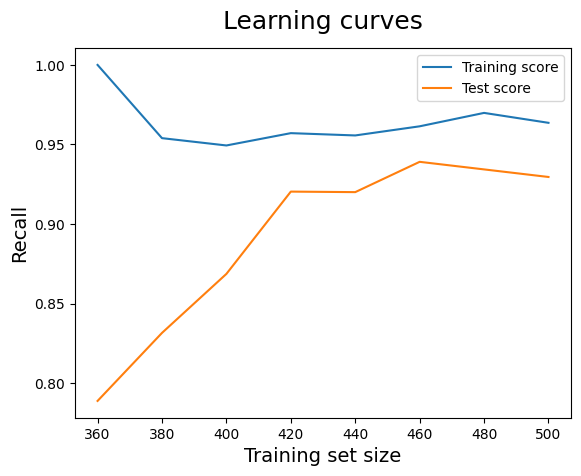

In [102]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylabel('Recall', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()

In [103]:
train_scores

array([[       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan],
       [       nan,        nan,   

In [104]:
display(df['event_time'].min(), df['event_time'].max())

'2019-10-01 00:00:00 UTC'

'2019-10-01 04:28:27 UTC'

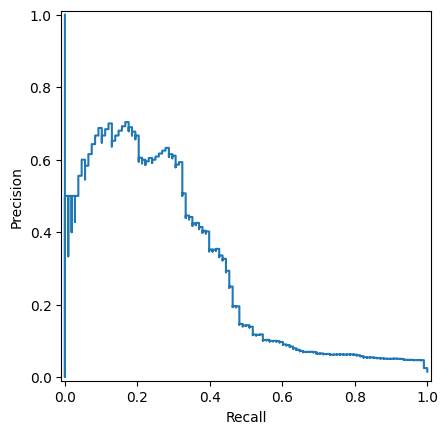

In [105]:
y_pred_proba = model.predict_proba(X_test_processed)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

In [106]:
from sklearn.metrics import classification_report
print(classification_report(y_test, model.predict(X_test_processed)))

              precision    recall  f1-score   support

           0       1.00      0.71      0.83      7078
           1       0.05      0.94      0.09       108

    accuracy                           0.72      7186
   macro avg       0.52      0.82      0.46      7186
weighted avg       0.98      0.72      0.82      7186

